## Missing Values
***

missing values occurs in dataset when some of the informations is not stored for variable there are 3 mechanisms

### 1. Missing completely at Random

missing completely at random (MCAR) is a type of missing data mechanism in  which the probability of a value being missed is unrelated to both the oberved data and the missing data .In other words if the data is MCAR, the missing values are randomly distributed throughout the dataset,and there is no systematic reason for why they are missing 

For example:In a survey about the prevelance of a certain disease the missing data might be MCAR if the survey participants with missing values for certain questions were selected randomly and their missing responses are not related to their disease status or any other variables measured in the survey.

### 2. Missing at Random MAR:

Missing at random (MAR) is a type of missing data mechanism in which the probability of a value being missing depends only on the observed data, but not on the missing data.Here are few example of missing at random.

Income data :suppose you are collecting income data from a group of people, but some participants choose not to report their income if the decision to report or not report income is related to the participant age or gender but not to their income level then data is missing at random 

Medical data: suppose you are collecting medical data on patients ,including their blood pressure but some  patients do not report theri blood pressure if the patients who do not report their blood pressure are more likely  to be  younger or have healthier lifestyle but the missingness is not related to their actual blood pressure values then the data is missing at random.



### 3. Missing data not at random (MNAR)

it is a type of missing data mechanism where the probability of missing values depends on the value of the missing data itself in other words if the data is MNAR the missingness is not random and is dependent on unobserved or unmeasured factors that are associated with the missing values.

For example:
suppose you are collecting on the income and job satisfaction of employees in a company if employees who are less  satisfied  with their jobs are more likely to refuse to report theri income then the data is not missing at random in this case the missingness is dependent on job satisfaction which is not directly observed or measured.

In [1]:
import seaborn as sns


In [2]:
df=sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [11]:
df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().any(axis=0)

survived       False
pclass         False
sex            False
age             True
sibsp          False
parch          False
fare           False
embarked        True
class          False
who            False
adult_male     False
deck            True
embark_town     True
alive          False
alone          False
dtype: bool

In [12]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [14]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [16]:
##delete the rows : but you will lose the data 
df.shape


(891, 15)

In [ ]:
df.dropna().shape
#we lost huge amount of data doing this -->not a very good idea

(182, 15)

In [ ]:
#column wise
df.dropna(axis=1).shape
#df.dropna(axis=1,inplace=True) to make it a permanent operation

(891, 11)

### imputation missing values

### 1. Mean Value Imputation

<Axes: xlabel='age', ylabel='Count'>

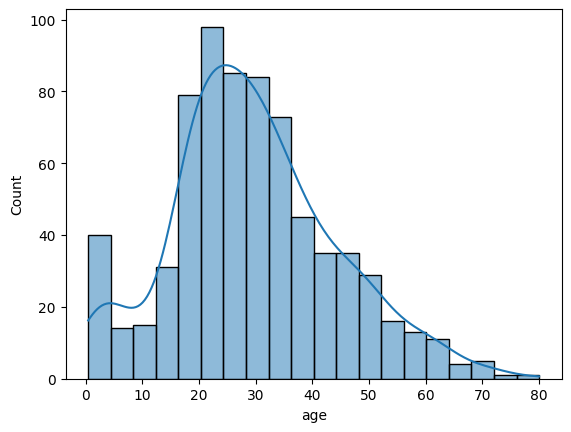

In [ ]:
sns.histplot(df['age'],kde=True)
#kernel destination estimate(KDE)

In [32]:
df['Age_mean']=df['age'].fillna(df['age'].mean())

In [33]:
df[['Age_mean',"age"]]

,Age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


In [34]:
#mean value works well when we have normally distributed data

### 2.Median Value Imputation

we will use this when we have outlier in data 
(data is left or right skewed)

In [36]:
df['age_median']=df['age'].fillna(df['age'].median())

In [38]:
df[['age_median','Age_mean','age']]

,age_median,Age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


### 3. Mode Imputation tehcnique --Categorical Values


In [42]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_median,Age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0,62.0


In [43]:
df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [ ]:
df[df['embarked'].notna()] #this code gave all the values in which embarked coloumn dosent hava na value



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_median,Age_mean,age_median
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.000000,22.000000,22.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.000000,38.000000,38.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.000000,26.000000,26.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.000000,35.000000,35.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.000000,35.000000,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,27.000000,27.000000,27.0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,19.000000,19.000000,19.0
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,29.699118,29.699118,28.0
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,26.000000,26.000000,26.0


In [48]:
mode_value=df[df['embarked'].notna()]['embarked'].mode()[0]
#this will further get me the embarked coloumn and i apply mode

In [49]:
df['embarked_mode']=df['embarked'].fillna(mode_value)
#fills all na value with modevalue

In [50]:
df[['embarked_mode','embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [51]:
df['embarked_mode'].isnull().sum()

np.int64(0)

In [52]:
df['embarked'].isnull().sum()

np.int64(2)

### 4.random value imputation 
select any value from the columns and replace the nan value with it 